In [ ]:
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import time

In [8]:
data_dir = Path("Data/CAL")
sensors = ["ATS", "ENG", "PS", "RDS", "RHS", "TIRS", "WS"]
dataframes=[]
for sensor in sensors:
    dataframes.append(pd.read_csv(data_dir/"CAL_{} _SOL_01_100.csv".format(sensor)))

In [ ]:
for dataframe in dataframes:
    print(dataframe.head())
    

          SCLK                LMST           LTST  ATS_LOCAL_TEMP1  \
0  667042430.0  00001M16:04:58.225  0001 15:27:28           253.31   
1  667042431.0  00001M16:04:59.198  0001 15:27:29           253.33   
2  667042432.0  00001M16:05:00.171  0001 15:27:30           253.54   
3  667042433.0  00001M16:05:01.145  0001 15:27:31           253.91   
4  667042434.0  00001M16:05:02.118  0001 15:27:32           253.85   

   ATS_LOCAL_TEMP2  ATS_LOCAL_TEMP3  ATS_LOCAL_TEMP4  ATS_LOCAL_TEMP5  sol  
0           271.93           254.64           246.60           252.99    1  
1           271.86           254.84           246.34           253.12    1  
2           271.99           255.03           246.37           253.02    1  
3           271.98           255.05           246.57           253.41    1  
4           272.11           255.05           246.24           253.68    1  
        SCLK                LMST           LTST  ICU_Analog_TH_HK_TM  \
0  667042253  00001M16:02:05.959  0001 15:24:

In [16]:
dataframes[0].head()

,SCLK,LMST,LTST,ATS_LOCAL_TEMP1,ATS_LOCAL_TEMP2,ATS_LOCAL_TEMP3,ATS_LOCAL_TEMP4,ATS_LOCAL_TEMP5,sol
0,667042430.0,00001M16:04:58.225,0001 15:27:28,253.31,271.93,254.64,246.60,252.99,1
1,667042431.0,00001M16:04:59.198,0001 15:27:29,253.33,271.86,254.84,246.34,253.12,1
2,667042432.0,00001M16:05:00.171,0001 15:27:30,253.54,271.99,255.03,246.37,253.02,1
3,667042433.0,00001M16:05:01.145,0001 15:27:31,253.91,271.98,255.05,246.57,253.41,1
4,667042434.0,00001M16:05:02.118,0001 15:27:32,253.85,272.11,255.05,246.24,253.68,1


In [29]:
# generate time column with 1 sec resolution from lMST
def create_time_column(dataframe):
    split = dataframe["LMST"].str.split("M", expand=True)

    # Sol number already exists
    
    # Convert to time
    dataframe["LMST_time"] = pd.to_datetime(
        split[1],
        format="%H:%M:%S.%f"
    ).dt.time

    dataframe["mars_datetime"] = (pd.to_timedelta(dataframe["sol"], unit="D") +
    pd.to_timedelta(split[1].str.split(".").str[0])
    )
    return dataframe
    


In [30]:
create_time_column(dataframes[0]).head()

,SCLK,LMST,LTST,ATS_LOCAL_TEMP1,ATS_LOCAL_TEMP2,ATS_LOCAL_TEMP3,ATS_LOCAL_TEMP4,ATS_LOCAL_TEMP5,sol,LMST_time,mars_datetime
0,667042430.0,00001M16:04:58.225,0001 15:27:28,253.31,271.93,254.64,246.60,252.99,1,16:04:58.225000,1 days 16:04:58
1,667042431.0,00001M16:04:59.198,0001 15:27:29,253.33,271.86,254.84,246.34,253.12,1,16:04:59.198000,1 days 16:04:59
2,667042432.0,00001M16:05:00.171,0001 15:27:30,253.54,271.99,255.03,246.37,253.02,1,16:05:00.171000,1 days 16:05:00
3,667042433.0,00001M16:05:01.145,0001 15:27:31,253.91,271.98,255.05,246.57,253.41,1,16:05:01.145000,1 days 16:05:01
4,667042434.0,00001M16:05:02.118,0001 15:27:32,253.85,272.11,255.05,246.24,253.68,1,16:05:02.118000,1 days 16:05:02


<Axes: xlabel='mars_datetime'>

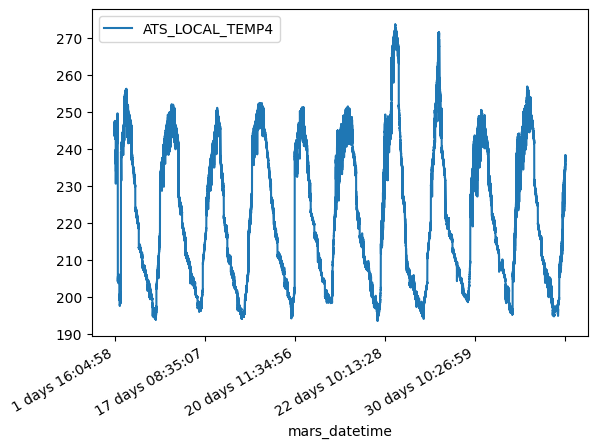

In [32]:
dataframes[0].head(1000000).plot(x="mars_datetime", y="ATS_LOCAL_TEMP4")

In [12]:
from pathlib import Path
import pandas as pd

# Your actual path (adjust slashes for Windows)
data_dir = Path(r"C:\Users\Anwender\Documents\Weiterbildung Stackfuel\Portfolio\Data\CAL")

# List all CSV files
csv_files = sorted(data_dir.glob("*.csv"))
print(f"Found {len(csv_files)} CSV files:\n")
for f in csv_files:
    print(f"  {f.name}")

# Read and inspect the first file
if csv_files:
    print(f"\n{'='*70}")
    print(f"Inspecting: {csv_files[0].name}")
    print(f"{'='*70}\n")
    
    df = pd.read_csv(csv_files[0])
    print(f"Shape: {df.shape} (rows, columns)")
    print(f"\nFirst 20 column names:")
    for i, col in enumerate(df.columns[:20], 1):
        print(f"  {i:2d}. {col}")
    
    print(f"\nFirst 2 data rows:")
    print(df.head(2))
    
    print(f"\nData types:")
    print(df.dtypes.head(10))
    
    print(f"\nTime columns sample:")
    if 'SCLK' in df.columns:
        print(df[['SCLK', 'LMST', 'LTST']].head(2))

Found 40 CSV files:

  CAL_ATS _SOL_01_100.csv
  CAL_ATS _SOL_101_200.csv
  CAL_ATS _SOL_201_300.csv
  CAL_ATS _SOL_301_400.csv
  CAL_ATS _SOL_401_500.csv
  CAL_ATS _SOL_601_700.csv
  CAL_ENG _SOL_01_100.csv
  CAL_ENG _SOL_101_200.csv
  CAL_ENG _SOL_201_300.csv
  CAL_ENG _SOL_301_400.csv
  CAL_ENG _SOL_401_500.csv
  CAL_ENG _SOL_601_700.csv
  CAL_PS _SOL_01_100.csv
  CAL_PS _SOL_101_200.csv
  CAL_PS _SOL_201_300.csv
  CAL_PS _SOL_301_400.csv
  CAL_PS _SOL_401_500.csv
  CAL_PS _SOL_601_700.csv
  CAL_RDS _SOL_01_100.csv
  CAL_RDS _SOL_101_200.csv
  CAL_RDS _SOL_201_300.csv
  CAL_RDS _SOL_301_400.csv
  CAL_RDS _SOL_401_500.csv
  CAL_RDS _SOL_601_700.csv
  CAL_RHS _SOL_01_100.csv
  CAL_RHS _SOL_101_200.csv
  CAL_RHS _SOL_201_300.csv
  CAL_RHS _SOL_301_400.csv
  CAL_RHS _SOL_401_500.csv
  CAL_RHS _SOL_601_700.csv
  CAL_TIRS _SOL_01_100.csv
  CAL_TIRS _SOL_101_200.csv
  CAL_TIRS _SOL_201_300.csv
  CAL_TIRS _SOL_301_400.csv
  CAL_TIRS _SOL_401_500.csv
  CAL_TIRS _SOL_601_700.csv
  CAL_WS _SOL

In [13]:
from pathlib import Path
import pandas as pd

data_dir = Path(r"C:\Users\Anwender\Documents\Weiterbildung Stackfuel\Portfolio\Data\CAL")

# Check PS and RDS
for sensor in ['PS', 'RDS']:
    files = list(data_dir.glob(f"CAL_{sensor} _SOL_01_100.csv"))
    if files:
        print(f"\n{'='*70}")
        print(f"{sensor} columns:")
        print(f"{'='*70}")
        df = pd.read_csv(files[0], nrows=1)
        for i, col in enumerate(df.columns, 1):
            print(f"  {i:2d}. {col}")
        print(f"\nSample data:")
        print(df.iloc[0])


PS columns:
   1. SCLK
   2. LMST
   3. LTST
   4. BAROCAP1_PRESSURE
   5. BAROCAP1_PRESSURE_UNCERTAINTY
   6. BAROCAP2_PRESSURE
   7. BAROCAP2_PRESSURE_UNCERTAINTY
   8. BAROCAP3_PRESSURE
   9. BAROCAP3_PRESSURE_UNCERTAINTY
  10. THERMOCAP1_TEMP
  11. THERMOCAP1_TEMP_UNCERTAINTY
  12. THERMOCAP2_TEMP
  13. THERMOCAP2_TEMP_UNCERTAINTY
  14. PRESSURE_MEASUREMENT_MODE
  15. TRANSDUCER
  16. sol

Sample data:
SCLK                                      667042464
LMST                             00001M16:05:31.315
LTST                                  0001 15:28:01
BAROCAP1_PRESSURE                            715.96
BAROCAP1_PRESSURE_UNCERTAINTY                   NaN
BAROCAP2_PRESSURE                            715.84
BAROCAP2_PRESSURE_UNCERTAINTY                   NaN
BAROCAP3_PRESSURE                               0.0
BAROCAP3_PRESSURE_UNCERTAINTY                   NaN
THERMOCAP1_TEMP                              298.28
THERMOCAP1_TEMP_UNCERTAINTY                     NaN
THERMOCAP2_TEMP  